<a href="https://colab.research.google.com/github/AufanT/AufanT-BigData26_B_2411532011_AufanTaufiqurrahman/blob/main/Praktikum_3/BD_P03_2411532011_AufanTaufiqurrahman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## K-1. Menyiapkan lingkungan
Cek versi pustaka, mount Drive, lalu siapkan folder kerja. Fungsi `ukur()` diambil dari Praktikum 1, ditambah `catat_sumber()` untuk mencatat lineage tiap sumber data.

`DIR_SIMPAN` aku arahkan ke `Praktikum3` sesuai bagian J (di kode modul tertulis `Praktikum2`).

In [1]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
  try:
    mod = __import__(nama)
    print(f"{nama:11s}: {mod.__version__}")
  except ImportError:
    print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
 os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []
def rss_mb():
  return proses.memory_info().rss / 1024**2
def cek_ram(label):
    vm = psutil.virtual_memory()
    print(f"[{label}] RAM: {vm.used/1024**3:.1f} / {vm.total/1024**3:.1f} GB "
          f"({vm.percent}%) | proses ini: {rss_mb():,.0f} MB")
def ukur(label, fungsi):
 m0, t0 = rss_mb(), time.perf_counter()
 hasil = fungsi()
 detik = time.perf_counter() - t0
 catatan.append({"langkah": label, "detik": round(detik, 2),
 "delta_rss_mb": round(rss_mb() - m0, 1)})
 print(f"[{label}] {detik:.2f} s")
 return hasil

# --- Baru di Praktikum 3: catatan asal-usul data (lineage) ---
lineage = []
def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
 lineage.append({
 "sumber": nama, "asal": asal,
 "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
 "jumlah_baris": jumlah_baris, "keterangan": keterangan,
 })
 print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Mounted at /content/drive


## K-2. Akuisisi 1 — Unduhan berkala
File diunduh ke `.part` dulu, baru di-rename ke nama final supaya tidak ada file setengah jadi. Kalau file sudah ada, unduhan dilewati (cache).

**Perubahan dari modul:**
- indentasi `unduh_aman` diperbaiki, versi awal tidak pernah mengunduh (fungsi langsung mengembalikan `None`)
- `shutil.copyfileobj(r.raw, f)` diganti `r.iter_content()` karena `r.raw` tidak men-decode kompresi HTTP

In [2]:
import requests, shutil
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            os.replace(sementara, tujuan)  # atomik
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)  # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
  print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
 "trip_distance", "PULocationID", "DOLocationID", "payment_type",
 "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")
zona.head()


[unduh trip] 0.34 s
[unduh zona] 0.05 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 1.80 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


## K-3. Akuisisi 2 — API JSON (Open-Meteo)
Cuaca per jam NYC, zona waktu `America/New_York` supaya sama dengan waktu di data TLC. Jumlah baris dicek terhadap jumlah jam di rentang tanggal; kalau beda, berarti ada jam yang hilang.

In [3]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:  # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):  # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()  # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                              "temperature_2m": "suhu_c",
                              "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
jam_harapan = ((pd.Timestamp("2023-01-31") - pd.Timestamp("2023-01-01")).days + 1) * 24
print(f"jumlah jam harapan: {jam_harapan} | baris cuaca: {len(cuaca)}")
cuaca.head()

[ambil cuaca] 0.45 s
[lineage] cuaca: 744 baris
jumlah jam harapan: 744 | baris cuaca: 744


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


## K-5. Akuisisi 3 — Basis data SQLite
SQLite dipakai sebagai simulasi sistem operasional: tabel `tarif_referensi` dan 300.000 baris `trip_operasional`. Koneksi pakai engine SQLAlchemy supaya tidak muncul UserWarning di pandas 2.x, dan pembacaan dilakukan per 50.000 baris.

In [4]:
from sqlalchemy import create_engine
PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
    SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
    FROM trip_operasional
    WHERE total_amount > 0
    GROUP BY payment_type
    ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                          engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


## K-6. Profiling kualitas data
Profiling pakai 8 aturan dari enam dimensi kualitas. Ambang yang dipakai:
- jarak valid 0,01–100 mil
- durasi wajar 1–180 menit
- `total_amount` > 0 dan ≥ `fare_amount`
- waktu jemput masih di Januari 2023

In [5]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
display(profil)

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])

aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}

laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan

,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


## K-7. Nilai hilang dan duplikat
Kolom yang punya nilai hilang: `passenger_count`. Empat strategi dibandingkan (buang, median, modus, median per jam) untuk melihat dampaknya ke distribusi.

**Keputusan:**
- isi dengan median per jam + tambah penanda `passenger_count_hilang`, supaya informasi "hilang" tetap tersimpan kalau ternyata tidak acak
- duplikat dihapus berdasarkan kunci 5 kolom, bukan duplikat penuh

In [6]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour
strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}
banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
display(banding)

# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())  # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

persen hilang: 2.339


,strategi,n,mean,median,std
0,1_dibuang,2995023,1.3625,1.0,0.8961
1,2_isi_median,3066766,1.3541,1.0,0.8873
2,3_isi_modus,3066766,1.3541,1.0,0.8873
3,4_median_perjam,3066766,1.3541,1.0,0.8873


duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


## K-8. Outlier dan join
Outlier dicek pakai IQR dan Z-score untuk `trip_distance`, `durasi_menit`, dan `total_amount`.

**Keputusan:**
- baris di luar ambang K-6 (jarak, durasi, total) **dibuang**
- tarif mahal hanya **ditandai** (`tarif_ekstrem`), tidak dibuang, karena bisa jadi perjalanan bandara yang valid
- `trip_distance` di-*winsorize* ke persentil 99,5 di kolom baru `trip_distance_capped`; kolom asli tetap

Semua join pakai `how="left"` + `validate="many_to_one"`, lalu jumlah baris sebelum dan sesudah dicek.

In [7]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

display(ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"]))

# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (trip["trip_distance"].between(0.01, 100)
         & trip["durasi_menit"].between(1, 180)
         & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)
print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

# --- Join 1: tabel zona (dimensi) ---
print("kunci zona unik?", zona["LocationID"].is_unique)  # WAJIB diperiksa
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one")  # gagal keras bila tidak 1:1
bersih = bersih.drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                      on="payment_type", how="left", validate="many_to_one")

# --- Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu) ---
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94


3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


## K-9. Encoding dan scaling
Fitur turunan: hari, akhir pekan, kecepatan, tarif per mil, dan penanda hujan (> 0,1 mm). Scaler dan encoder di-*fit* hanya di data latih (80%) supaya tidak terjadi data leakage; data uji cukup di-*transform*.

In [8]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]
contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])  # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])  # transform saja, tanpa fit ulang
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


## K-10. Pipeline, validasi, dan penyimpanan berpartisi
Semua langkah dibungkus jadi satu fungsi `pipeline()` dan divalidasi terhadap kontrak skema. Hasil disimpan sebagai Parquet berpartisi `borough_naik` karena nilainya sedikit dan sering dipakai sebagai filter.

Catatan: output `pipeline()` punya kolom lebih sedikit daripada `bersih` (tanpa `passenger_count_hilang`, `tarif_ekstrem`, `trip_distance_capped`, `zona_naik`), mengikuti kode modul.

In [9]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona)
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))
    df = df.drop_duplicates(subset=KUNCI)
    df = df[df["trip_distance"].between(0.01, 100)
            & df["durasi_menit"].between(1, 180)
            & (df["total_amount"] > 0)]
    df = (df.merge(z[["LocationID", "Borough"]]
                   .rename(columns={"Borough": "borough_naik"}),
                   left_on="PULocationID", right_on="LocationID",
                   how="left", validate="many_to_one")
            .drop(columns="LocationID")
            .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                   on="payment_type", how="left", validate="many_to_one"))
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
shutil.rmtree(OUT, ignore_errors=True)  # overwrite: hapus keluaran lama, SEBELUM menulis
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

for f in ["laporan_kualitas.csv", "lineage.csv", "pengukuran_kinerja.csv", "trips_bersih.zip"]:
    p = os.path.join(DIR_SIMPAN, f)
    print(f"{f:25s}", f"tersimpan ({os.path.getsize(p)/1024**2:.2f} MB)" if os.path.exists(p) else "TIDAK ADA")


Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 7.65 s
[tulis parquet berpartisi] 3.51 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True
laporan_kualitas.csv      tersimpan (0.00 MB)
lineage.csv               tersimpan (0.00 MB)
pengukuran_kinerja.csv    tersimpan (0.00 MB)
trips_bersih.zip          tersimpan (55.79 MB)


## K-11. Versi PySpark
Pipeline yang sama dijalankan di PySpark. Tabel zona di-*broadcast* supaya join tidak perlu shuffle.

**Perubahan dari modul:** kolom waktu terbaca sebagai `TIMESTAMP_NTZ` dan tidak bisa langsung di-cast ke `long`. Solusinya di-cast ke `timestamp` dulu, dan zona waktu sesi diset ke UTC supaya durasi tidak bergeser karena DST. Jumlah baris Spark dicetak untuk dicocokkan dengan hasil pandas.

In [10]:
!pip install -q pyspark==3.5.1
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.sql.session.timeZone", "UTC")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
        .withColumn("durasi_menit",
                (F.col("tpep_dropoff_datetime").cast("timestamp").cast("long")
                 - F.col("tpep_pickup_datetime").cast("timestamp").cast("long")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                     "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona),  # tabel kecil: broadcast
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

n_spark = ukur("spark: hitung baris bersih", lambda: sbersih.count())
print(f"baris bersih Spark: {n_spark:,} | pandas: {len(hasil):,} | selisih: {n_spark - len(hasil):,}")
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")
sbersih.explain()  # cari BroadcastHashJoin, bukan SortMergeJoin
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 11.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[spark: hitung baris bersih] 18.15 s
baris bersih Spark: 2,986,910 | pandas: 2,986,910 | selisih: 0
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, pas

# Q. Latihan

## Q-1. Kecepatan unduh
`unduh_aman` ditambah pengukuran waktu dan ukuran file untuk menghitung MB/detik. Pengujian pakai file terpisah (`uji_latihan1.parquet`) supaya data mentah asli tidak tersentuh. File uji dihapus di awal sel, jadi panggilan pertama pasti mengunduh dan panggilan kedua pasti kena cache.

In [11]:
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik + laporan kecepatan."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            t0 = time.perf_counter()
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk)
            detik = time.perf_counter() - t0
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            mb = os.path.getsize(sementara) / 1024**2
            os.replace(sementara, tujuan)  # atomik
            print(f"terunduh {mb:.2f} MB dalam {detik:.2f} s -> {mb/detik:.2f} MB/s")
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

PATH_UJI = os.path.join(DIR_MENTAH, "uji_latihan1.parquet")
if os.path.exists(PATH_UJI):
    os.remove(PATH_UJI)  # supaya panggilan pertama benar-benar mengunduh

print("Panggilan 1:")
ukur("latihan1: unduh ke-1", lambda: unduh_aman(URL_TRIP, PATH_UJI))
print("Panggilan 2:")
ukur("latihan1: unduh ke-2", lambda: unduh_aman(URL_TRIP, PATH_UJI))

Panggilan 1:
terunduh 45.46 MB dalam 0.40 s -> 113.22 MB/s
[latihan1: unduh ke-1] 0.40 s
Panggilan 2:
cache ditemukan: uji_latihan1.parquet
[latihan1: unduh ke-2] 0.00 s


'/content/lapisan_mentah/uji_latihan1.parquet'

## Q-2. Dua aturan kualitas baru
- validitas: `tip_amount >= 0` — tip tidak mungkin negatif
- konsistensi: `tip_amount <= total_amount` — tip adalah bagian dari total

Aturan dihitung dari data mentah (dibaca ulang) supaya bisa dibandingkan langsung dengan 8 aturan di K-6. Tabel `laporan` asli tidak ditimpa.

In [12]:
mentah = pd.read_parquet(PATH_TRIP, columns=KOLOM)

aturan_q2 = dict(aturan)  # salinan 8 aturan dari K-6
aturan_q2.update({
    "validitas: tip_amount >= 0": mentah["tip_amount"] >= 0,
    "konsistensi: tip <= total": mentah["tip_amount"] <= mentah["total_amount"],
})

laporan_q2 = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan_q2.items()
]).sort_values("persen_gagal", ascending=False)
display(laporan_q2)

del mentah; gc.collect()

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
9,konsistensi: tip <= total,3041562,25204,0.822
6,konsistensi: total >= fare,3041743,25023,0.816
8,validitas: tip_amount >= 0,3066541,225,0.007
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


60

## Q-3. Join lokasi tujuan
Pola join sama dengan K-8: `how="left"` + `validate="many_to_one"`, lalu jumlah baris dicek. Join hanya pakai kolom `borough_naik` dan `DOLocationID` supaya hemat memori dan `bersih` tidak berubah. Borough kosong (NaN) tetap dihitung supaya tidak ada baris yang hilang diam-diam.

In [13]:
zona_turun = zona[["LocationID", "Borough"]].rename(
    columns={"LocationID": "DOLocationID", "Borough": "borough_turun"})

n0 = len(bersih)
od = bersih[["borough_naik", "DOLocationID"]].merge(
    zona_turun, on="DOLocationID", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(od):,} (harus sama)")
print("borough tujuan kosong:", od["borough_turun"].isna().sum())

top10 = (od.groupby(["borough_naik", "borough_turun"], dropna=False)
           .size().rename("jumlah")
           .sort_values(ascending=False).head(10).reset_index())
top10["persen"] = (100 * top10["jumlah"] / len(od)).round(2)
display(top10)

baris 2,986,910 -> 2,986,910 (harus sama)
borough tujuan kosong: 9511


,borough_naik,borough_turun,jumlah,persen
0,Manhattan,Manhattan,2491566,83.42
1,Queens,Manhattan,155261,5.20
2,Manhattan,Queens,82354,2.76
3,Manhattan,Brooklyn,62986,2.11
4,Queens,Queens,59146,1.98
5,Queens,Brooklyn,42187,1.41
6,Unknown,Manhattan,18432,0.62
7,Unknown,Unknown,13562,0.45
8,Manhattan,Bronx,8865,0.30
9,Brooklyn,Brooklyn,7910,0.26


## Q-4. MinMaxScaler vs StandardScaler
Scaler tetap di-*fit* hanya di data latih (sama seperti K-9). Yang dibandingkan: nilai min dan max hasil kedua scaler di data latih, ditambah hasil MinMax di data uji.

In [14]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler().fit(latih[FITUR_NUM])  # fit HANYA di data latih
latih_mm = mm.transform(latih[FITUR_NUM])
uji_mm = mm.transform(uji[FITUR_NUM])

banding_skala = pd.DataFrame({
    "fitur": FITUR_NUM,
    "standard_min": latih_num.min(axis=0).round(3),
    "standard_max": latih_num.max(axis=0).round(3),
    "minmax_min": latih_mm.min(axis=0).round(3),
    "minmax_max": latih_mm.max(axis=0).round(3),
    "minmax_uji_min": uji_mm.min(axis=0).round(3),
    "minmax_uji_max": uji_mm.max(axis=0).round(3),
})
display(banding_skala)

,fitur,standard_min,standard_max,minmax_min,minmax_max,minmax_uji_min,minmax_uji_max
0,trip_distance_capped,-0.794,4.247,0.0,1.0,0.0,1.00
1,durasi_menit,-1.226,13.925,0.0,1.0,0.0,0.91
2,suhu_c,-2.288,3.347,0.0,1.0,0.0,1.00


## Q-5. Uji `validate="many_to_one"`
Satu baris di salinan tabel zona digandakan (zona penjemputan tersibuk). Join dengan `validate` harus gagal dengan `MergeError`. Sebagai pembanding, join tanpa `validate` dijalankan untuk melihat berapa baris yang bertambah diam-diam. Tabel `zona` asli tidak diubah.

In [15]:
from pandas.errors import MergeError

id_ramai = bersih["PULocationID"].mode()[0]
zona_rusak = pd.concat([zona, zona[zona["LocationID"] == id_ramai]], ignore_index=True)
print(f"ID digandakan: {id_ramai} | kunci zona_rusak unik? {zona_rusak['LocationID'].is_unique}")

kiri = bersih[["PULocationID"]]
kanan = zona_rusak[["LocationID", "Borough"]]

# 1) dengan validate -> harus error
try:
    kiri.merge(kanan, left_on="PULocationID", right_on="LocationID",
               how="left", validate="many_to_one")
    print("join lolos (seharusnya TIDAK)")
except MergeError as e:
    print("MergeError:", e)

# 2) tanpa validate -> baris bertambah diam-diam
tanpa = kiri.merge(kanan, left_on="PULocationID", right_on="LocationID", how="left")
print(f"tanpa validate: {len(kiri):,} -> {len(tanpa):,} baris (+{len(tanpa)-len(kiri):,})")

del zona_rusak, tanpa, kiri, kanan; gc.collect()
print(f"zona asli: {len(zona)} baris, kunci unik? {zona['LocationID'].is_unique}")

ID digandakan: 132 | kunci zona_rusak unik? False
MergeError: Merge keys are not unique in right dataset; not a many-to-one merge
tanpa validate: 2,986,910 -> 3,139,750 baris (+152,840)
zona asli: 265 baris, kunci unik? True


## Q-6. Pipeline inkremental
Setiap bulan ditulis ke folder `bulan=YYYY-MM/` (dipartisi lagi per borough). Kalau folder bulan sudah ada, proses dilewati. Penulisan lewat folder `.tmp` lalu di-rename, supaya folder bulan tidak pernah setengah jadi.

**Keputusan:** baris dengan waktu jemput di luar bulan tersebut dibuang, supaya tidak ada baris tanpa pasangan cuaca dan tidak ada data yang tercampur antar-bulan.

Bukti idempoten: jumlah berkas di folder output dihitung sebelum dan sesudah panggilan kedua.

In [16]:
DIR_INKR = os.path.join(DIR_KURASI, "trips_inkremental")
os.makedirs(DIR_INKR, exist_ok=True)

def ambil_cuaca_bulan(bulan):
    awal = pd.Timestamp(bulan + "-01")
    akhir = awal + pd.offsets.MonthEnd(0)
    c = ambil_cuaca(awal.strftime("%Y-%m-%d"), akhir.strftime("%Y-%m-%d"))
    c["time"] = pd.to_datetime(c["time"])
    return c.rename(columns={"time": "jam_mulai", "temperature_2m": "suhu_c",
                             "precipitation": "hujan_mm"})

def pipeline_inkremental(bulan):
    """bulan: 'YYYY-MM'. Hanya diproses kalau folder bulan belum ada."""
    dir_bulan = os.path.join(DIR_INKR, f"bulan={bulan}")
    if os.path.exists(dir_bulan):
        print(f"[{bulan}] sudah ada, dilewati")
        return 0

    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    path = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    unduh_aman(url, path)
    df = pipeline(path, PATH_ZONA, ambil_cuaca_bulan(bulan), tarif_referensi)

    awal = pd.Timestamp(bulan + "-01")
    akhir = awal + pd.offsets.MonthBegin(1)
    n0 = len(df)
    df = df[(df["tpep_pickup_datetime"] >= awal) & (df["tpep_pickup_datetime"] < akhir)]
    print(f"[{bulan}] dibuang karena di luar bulan: {n0 - len(df):,}")

    sementara = dir_bulan + ".tmp"
    shutil.rmtree(sementara, ignore_errors=True)
    df.to_parquet(sementara, partition_cols=["borough_naik"], index=False)
    os.replace(sementara, dir_bulan)  # folder bulan muncul hanya jika penulisan selesai

    catat_sumber(f"trip {bulan}", url, len(df), "pipeline_inkremental")
    n = len(df)
    del df; gc.collect()
    return n

def hitung_berkas(d):
    return sum(len(f) for _, _, f in os.walk(d))

print("berkas awal:", hitung_berkas(DIR_INKR))
ukur("inkremental ke-1", lambda: pipeline_inkremental("2023-01"))
n1 = hitung_berkas(DIR_INKR)
print("berkas setelah panggilan 1:", n1)
ukur("inkremental ke-2", lambda: pipeline_inkremental("2023-01"))
n2 = hitung_berkas(DIR_INKR)
print("berkas setelah panggilan 2:", n2)
print("idempoten (tidak ada berkas baru)?", n1 == n2)

berkas awal: 0
cache ditemukan: yellow_tripdata_2023-01.parquet
Validasi lulus: 2,986,910 baris x 17 kolom
[2023-01] dibuang karena di luar bulan: 37
[lineage] trip 2023-01: 2,986,873 baris
[inkremental ke-1] 26.67 s
berkas setelah panggilan 1: 8
[2023-01] sudah ada, dilewati
[inkremental ke-2] 0.00 s
berkas setelah panggilan 2: 8
idempoten (tidak ada berkas baru)? True


# O. Analisis Hasil

## O-a. Distribusi `total_amount` sebelum vs sesudah
Sebelum = data mentah Januari. Sesudah = hasil `pipeline()`. Kedua histogram pakai bin dan sumbu-x yang sama (−50 s.d. 150 dolar). Sumbu-y pakai skala log supaya nilai negatif dan ekor kanan tetap terlihat. Jumlah nilai di luar rentang dicetak terpisah.

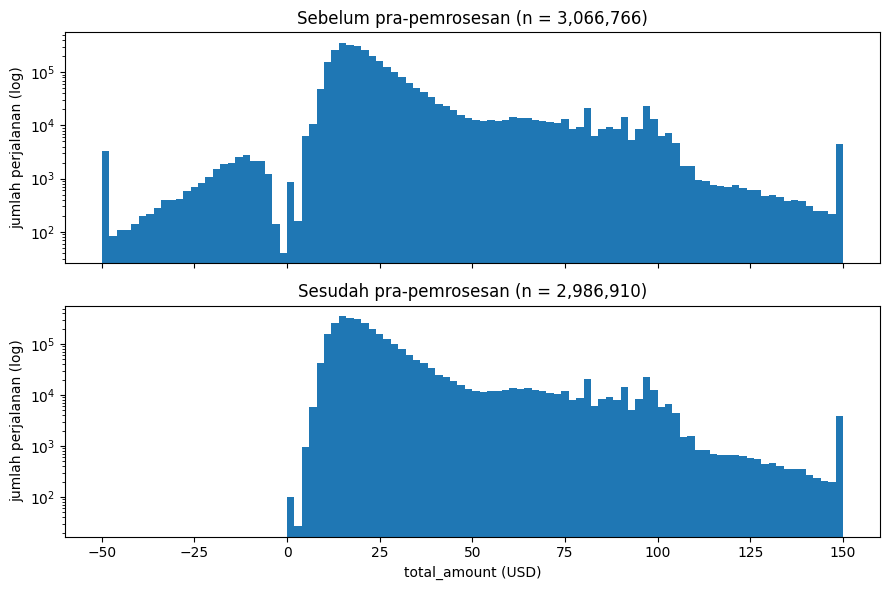

sebelum  | <= 0:  25,772 | > 150:  4,313 | median: 20.16 | max: 1,169.40
sesudah  | <= 0:       0 | > 150:  3,632 | median: 20.16 | max: 614.45


3426

In [17]:
import matplotlib.pyplot as plt

sebelum = pd.read_parquet(PATH_TRIP, columns=["total_amount"])["total_amount"]
sesudah = hasil["total_amount"]
BATAS = (-50, 150)
bins = np.linspace(*BATAS, 101)

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for a, s, judul in [(ax[0], sebelum, "Sebelum pra-pemrosesan"),
                    (ax[1], sesudah, "Sesudah pra-pemrosesan")]:
    a.hist(s.clip(*BATAS), bins=bins)
    a.set_yscale("log")
    a.set_title(f"{judul} (n = {len(s):,})")
    a.set_ylabel("jumlah perjalanan (log)")
ax[1].set_xlabel("total_amount (USD)")
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/histogram_total_amount.png", dpi=150)
plt.show()

for nama, s in [("sebelum", sebelum), ("sesudah", sesudah)]:
    print(f"{nama:8s} | <= 0: {(s <= 0).sum():>7,} | > 150: {(s > 150).sum():>6,} | "
          f"median: {s.median():.2f} | max: {s.max():,.2f}")
del sebelum; gc.collect()

## O-b. Waktu per tahap pipeline
Isi `pipeline()` dijalankan ulang per tahap supaya waktu baca dan waktu join bisa dipisah. Logika sama persis dengan K-10; jumlah baris akhir dicek terhadap `hasil`.

In [18]:
i0 = len(catatan)  # supaya yang diringkas hanya pengukuran di sel ini

df = ukur("O4: baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
z = ukur("O4: baca zona", lambda: pd.read_csv(PATH_ZONA))

def praproses(df):
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))
    df = df.drop_duplicates(subset=KUNCI)
    return df[df["trip_distance"].between(0.01, 100)
              & df["durasi_menit"].between(1, 180)
              & (df["total_amount"] > 0)]

df = ukur("O4: praproses (isi, dedup, filter)", lambda: praproses(df))
df = ukur("O4: join zona", lambda: df.merge(
    z[["LocationID", "Borough"]].rename(columns={"Borough": "borough_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one").drop(columns="LocationID"))
df = ukur("O4: join tarif", lambda: df.merge(
    tarif_referensi[["payment_type", "nama_pembayaran"]],
    on="payment_type", how="left", validate="many_to_one"))
df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
df = ukur("O4: join cuaca", lambda: df.merge(
    cuaca, on="jam_mulai", how="left", validate="many_to_one"))

print(f"\nbaris akhir: {len(df):,} | hasil K-10: {len(hasil):,} | sama? {len(df) == len(hasil)}")

o4 = pd.DataFrame(catatan[i0:])
o4["persen"] = (100 * o4["detik"] / o4["detik"].sum()).round(1)
display(o4)

t_baca = o4.loc[o4["langkah"].str.contains("baca"), "detik"].sum()
t_join = o4.loc[o4["langkah"].str.contains("join"), "detik"].sum()
print(f"baca: {t_baca:.2f} s | join: {t_join:.2f} s | join/baca: {t_join/t_baca:.2f}x")
del df; gc.collect()

[O4: baca trip] 1.26 s
[O4: baca zona] 0.00 s
[O4: praproses (isi, dedup, filter)] 2.84 s
[O4: join zona] 0.85 s
[O4: join tarif] 0.34 s
[O4: join cuaca] 0.70 s

baris akhir: 2,986,910 | hasil K-10: 2,986,910 | sama? True


,langkah,detik,delta_rss_mb,persen
0,O4: baca trip,1.26,245.4,21.0
1,O4: baca zona,0.00,0.0,0.0
2,"O4: praproses (isi, dedup, filter)",2.84,251.3,47.4
3,O4: join zona,0.85,205.1,14.2
4,O4: join tarif,0.34,136.7,5.7
5,O4: join cuaca,0.70,387.3,11.7


baca: 1.26 s | join: 1.89 s | join/baca: 1.50x


66

## O-c. Cakupan join dan susut data
Mengecek (1) zona mana yang tidak dapat pasangan dan apakah terkonsentrasi di jam tertentu, (2) tanggal baris tanpa cuaca, dan (3) sumbangan tiap filter terhadap baris yang dibuang.

In [19]:
# --- O.5: cakupan join ---
tanpa_zona = bersih[bersih["zona_naik"].isna()]
print("ID tanpa nama zona:\n", tanpa_zona["PULocationID"].value_counts().head(), "\n")
print("ID dengan borough kosong:\n",
      bersih.loc[bersih["borough_naik"].isna(), "PULocationID"].value_counts().head(), "\n")
print("tanggal baris tanpa cuaca:\n",
      bersih.loc[bersih["suhu_c"].isna(), "tpep_pickup_datetime"].dt.date.value_counts(), "\n")

jam_banding = pd.DataFrame({
    "semua_%": bersih["jam"].value_counts(normalize=True).sort_index() * 100,
    "tanpa_zona_%": tanpa_zona["jam"].value_counts(normalize=True).sort_index() * 100,
}).round(2)
jam_banding["selisih"] = (jam_banding["tanpa_zona_%"] - jam_banding["semua_%"]).round(2)
display(jam_banding.sort_values("selisih", key=abs, ascending=False).head(5))
print(f"median total_amount | semua: {bersih['total_amount'].median():.2f} | "
      f"tanpa zona: {tanpa_zona['total_amount'].median():.2f}")

# --- O.6: sumbangan tiap filter ---
m = pd.read_parquet(PATH_TRIP, columns=["tpep_pickup_datetime", "tpep_dropoff_datetime",
                                        "trip_distance", "total_amount"])
dur = (m["tpep_dropoff_datetime"] - m["tpep_pickup_datetime"]).dt.total_seconds() / 60
gagal = {
    "jarak": ~m["trip_distance"].between(0.01, 100),
    "durasi": ~dur.between(1, 180),
    "total": ~(m["total_amount"] > 0),
}
semua_gagal = gagal["jarak"] | gagal["durasi"] | gagal["total"]
susut = pd.DataFrame([
    {"filter": k, "gagal": int(v.sum()),
     "gagal_hanya_filter_ini": int((v & ~pd.concat([g for kk, g in gagal.items() if kk != k], axis=1).any(axis=1)).sum())}
    for k, v in gagal.items()
])
display(susut)
print(f"dibuang total oleh filter: {semua_gagal.sum():,} | "
      f"tersisa: {100 * len(hasil) / len(m):.2f}% dari {len(m):,} baris")
del m, dur, gagal, semua_gagal, tanpa_zona; _ = gc.collect()

ID tanpa nama zona:
 PULocationID
264    37609
Name: count, dtype: int64 

ID dengan borough kosong:
 PULocationID
265    340
Name: count, dtype: int64 

tanggal baris tanpa cuaca:
 tpep_pickup_datetime
2022-12-31    24
2023-02-01    10
2022-10-25     3
Name: count, dtype: int64 



,semua_%,tanpa_zona_%,selisih
jam,,,
14,6.25,7.18,0.93
21,5.28,6.08,0.80
18,7.06,6.34,-0.72
8,3.82,3.21,-0.61
20,5.42,6.03,0.61


median total_amount | semua: 20.16 | tanpa zona: 26.20


,filter,gagal,gagal_hanya_filter_ini
0,jarak,45950,22674
1,durasi,36383,11645
2,total,25772,20361


dibuang total oleh filter: 79,855 | tersisa: 97.40% dari 3,066,766 baris


# P. Studi Kasus — Tabel analitik untuk tim pricing

## P-1. Tabel analitik borough × jam
Satu baris = satu borough dalam satu jam. Kode inti mengikuti modul; `rata_tarif_per_mil` dan `rata_kecepatan` dihitung dengan **median** karena distribusinya miring. Kelompok dengan < 30 perjalanan dibuang karena terlalu kecil untuk disimpulkan.

Tambahan: jumlah jam per kelompok (hujan vs kering) dan selisih dalam persen, supaya kekuatan perbandingannya kelihatan. Borough "Unknown" tetap ada di tabel tapi tidak dipakai untuk kesimpulan.

In [20]:
tabel_analitik = (bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_tarif_per_mil=("tarif_per_mil", "median"),
         rata_kecepatan=("kecepatan_mph", "median"),
         suhu_c=("suhu_c", "first"), hujan=("hujan", "max"))
    .reset_index())

# Ambang minimum: kelompok yang terlalu kecil tidak bisa disimpulkan
tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]
print(tabel_analitik
      .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
      .median().unstack())

# --- Tambahan: jumlah jam + selisih persen ---
g = tabel_analitik.groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
n, med = g.size().unstack("hujan"), g.median().unstack("hujan")
jawaban = pd.DataFrame({
    "jam_kering": n.get(0), "jam_hujan": n.get(1),
    "tarif_per_mil_kering": med.get(0), "tarif_per_mil_hujan": med.get(1),
})
jawaban["selisih_%"] = (100 * (jawaban["tarif_per_mil_hujan"]
                               / jawaban["tarif_per_mil_kering"] - 1)).round(1)
display(jawaban)

print(f"\ntabel analitik: {len(tabel_analitik):,} baris x {tabel_analitik.shape[1]} kolom")
print("borough di tabel:", sorted(tabel_analitik["borough_naik"].unique()))

# Simpan
PATH_ANALITIK = f"{DIR_SIMPAN}/tabel_analitik.parquet"
tabel_analitik.to_parquet(PATH_ANALITIK, index=False)
print("tersimpan:", PATH_ANALITIK)

hujan               0        1
borough_naik                  
Brooklyn       6.9430   7.6550
Manhattan     10.5270  11.4000
Queens         5.4530   5.6365
Unknown        8.7255   9.8860


,jam_kering,jam_hujan,tarif_per_mil_kering,tarif_per_mil_hujan,selisih_%
borough_naik,,,,,
Brooklyn,125,17,6.9430,7.6550,10.3
Manhattan,637,107,10.5270,11.4000,8.3
Queens,583,96,5.4530,5.6365,3.4
Unknown,450,79,8.7255,9.8860,13.3



tabel analitik: 2,094 baris x 7 kolom
borough di tabel: ['Brooklyn', 'Manhattan', 'Queens', 'Unknown']
tersimpan: /content/drive/MyDrive/BigData/Praktikum3/tabel_analitik.parquet


## P-2. Cek faktor pengganggu: jam sibuk dan kecepatan
Perbandingan P-1 masih mentah; selisih tarif bisa muncul karena hujan kebetulan lebih sering di jam sibuk (14–19, temuan Praktikum 1). Di sini:
1. dicek proporsi jam hujan vs jam kering yang jatuh di jam sibuk
2. hujan hanya dibandingkan dengan kering pada jam yang sama (0–23), lalu selisihnya diringkas
3. dibandingkan kecepatan saat hujan vs kering

In [21]:
ta = tabel_analitik.copy()
ta["jam"] = ta["jam_mulai"].dt.hour
JAM_SIBUK = [14, 15, 16, 17, 18, 19]  # temuan Praktikum 1

# 1) Apakah hujan lebih sering di jam sibuk? (pakai Manhattan: 744 jam lengkap)
mh = ta[ta["borough_naik"] == "Manhattan"]
porsi = (mh.assign(jam_sibuk=mh["jam"].isin(JAM_SIBUK))
           .groupby("hujan")["jam_sibuk"].mean() * 100).round(1)
print(f"porsi jam sibuk | di jam kering: {porsi[0]}% | di jam hujan: {porsi[1]}%\n")

# 2) Perbandingan terkontrol: hujan vs kering pada jam yang sama
p = (ta.groupby(["borough_naik", "jam", "hujan"], observed=True)["rata_tarif_per_mil"]
       .median().unstack("hujan").dropna())
p["selisih_%"] = 100 * (p[1] / p[0] - 1)
terkontrol = p.groupby("borough_naik").agg(
    pasangan_jam=("selisih_%", "size"),
    selisih_terkontrol_pct=("selisih_%", "median"),
    persen_jam_hujan_lebih_mahal=("selisih_%", lambda s: 100 * (s > 0).mean()),
).round(1)
terkontrol["selisih_mentah_pct"] = jawaban["selisih_%"]
display(terkontrol)

# 3) Kecepatan: hujan vs kering
kec = (ta.groupby(["borough_naik", "hujan"], observed=True)["rata_kecepatan"]
         .median().unstack("hujan"))
kec["selisih_%"] = (100 * (kec[1] / kec[0] - 1)).round(1)
kec.columns = ["kecepatan_kering_mph", "kecepatan_hujan_mph", "selisih_%"]
display(kec)

porsi jam sibuk | di jam kering: 25.0% | di jam hujan: 25.2%



,pasangan_jam,selisih_terkontrol_pct,persen_jam_hujan_lebih_mahal,selisih_mentah_pct
borough_naik,,,,
Brooklyn,10,0.1,50.0,10.3
Manhattan,24,4.3,87.5,8.3
Queens,23,1.1,78.3,3.4
Unknown,19,8.9,89.5,13.3


,kecepatan_kering_mph,kecepatan_hujan_mph,selisih_%
borough_naik,,,
Brooklyn,12.2900,9.570,-22.1
Manhattan,11.1500,10.180,-8.7
Queens,26.9650,22.740,-15.7
Unknown,12.4925,10.885,-12.9


## P-3. Uji tanda
Kalau hujan tidak berpengaruh, peluang jam hujan lebih mahal daripada jam kering (di jam yang sama) adalah 50%. Uji binomial satu sisi dipakai untuk melihat apakah proporsi yang teramati bisa muncul karena kebetulan. Catatan: uji ini mengasumsikan tiap jam independen, dan itu hanya pendekatan.

In [22]:
from scipy.stats import binomtest

uji = p.groupby("borough_naik")["selisih_%"].agg(
    pasangan_jam="size", jam_hujan_lebih_mahal=lambda s: int((s > 0).sum()))
uji["p_value"] = [binomtest(k, n, 0.5, alternative="greater").pvalue
                  for k, n in zip(uji["jam_hujan_lebih_mahal"], uji["pasangan_jam"])]
uji["p_value"] = uji["p_value"].round(4)
display(uji)

,pasangan_jam,jam_hujan_lebih_mahal,p_value
borough_naik,,,
Brooklyn,10,5,0.6230
Manhattan,24,21,0.0001
Queens,23,18,0.0053
Unknown,19,17,0.0004


# R. Tugas Praktikum

## R.1a. Pipeline Januari + Juli 2023
Pakai `pipeline_inkremental()` dari Q-6. Kedua bulan ditulis ke direktori yang sama (`trips_inkremental/bulan=YYYY-MM/borough_naik=.../`). Januari sudah ada dari Q-6 sehingga otomatis dilewati; yang diproses hanya Juli.

DataFrame besar dari bagian K–P dihapus dulu supaya RAM cukup.

In [23]:
cek_ram("sebelum dibersihkan")
for nama in ["bersih", "hasil", "contoh", "latih", "uji"]:
    globals().pop(nama, None)
_ = gc.collect()
cek_ram("sesudah dibersihkan")

BULAN = ["2023-01", "2023-07"]
for b in BULAN:
    ukur(f"R1: inkremental {b}", lambda b=b: pipeline_inkremental(b))

print("\nisi direktori:", sorted(os.listdir(DIR_INKR)))
print("jumlah berkas:", hitung_berkas(DIR_INKR))
cek_ram("sesudah R.1a")

[sebelum dibersihkan] RAM: 6.1 / 12.7 GB (50.9%) | proses ini: 3,052 MB
[sesudah dibersihkan] RAM: 5.4 / 12.7 GB (45.3%) | proses ini: 2,324 MB
[2023-01] sudah ada, dilewati
[R1: inkremental 2023-01] 0.00 s
terunduh 46.12 MB dalam 0.39 s -> 117.00 MB/s
Validasi lulus: 2,817,657 baris x 17 kolom
[2023-07] dibuang karena di luar bulan: 50
[lineage] trip 2023-07: 2,817,607 baris
[R1: inkremental 2023-07] 11.06 s

isi direktori: ['bulan=2023-01', 'bulan=2023-07']
jumlah berkas: 16
[sesudah R.1a] RAM: 5.8 / 12.7 GB (48.1%) | proses ini: 2,690 MB


## R.1b. Bukti tidak ada duplikasi antar-bulan
1. bulan dari `tpep_pickup_datetime` harus sama dengan nama folder partisi `bulan`
2. `duplicated()` pada 5 kolom kunci di data gabungan harus 0; ini sekaligus mencakup duplikat lintas bulan
3. menjalankan ulang `pipeline_inkremental` untuk kedua bulan tidak boleh menambah berkas

Yang dibaca hanya kolom kunci + `bulan` supaya hemat memori. Dataset dua bulan disimpan sebagai `trips_bersih_2bulan.zip`.

In [24]:
cek = pd.read_parquet(DIR_INKR, columns=KUNCI + ["bulan"])
cek["bulan"] = cek["bulan"].astype(str)
print("baris per bulan:")
print(cek["bulan"].value_counts().sort_index(), "\n")

# 1) baris berada di folder bulan yang benar
salah_folder = (cek["tpep_pickup_datetime"].dt.strftime("%Y-%m") != cek["bulan"]).sum()
print(f"baris di folder bulan yang salah: {salah_folder:,}")

# 2) duplikat kunci di data gabungan (mencakup lintas bulan)
dup_gabungan = cek.duplicated(subset=KUNCI).sum()
print(f"duplikat kunci di data gabungan: {dup_gabungan:,} dari {len(cek):,} baris")

# 3) jalankan ulang -> tidak boleh ada berkas baru
n_sebelum = hitung_berkas(DIR_INKR)
for b in BULAN:
    pipeline_inkremental(b)
n_sesudah = hitung_berkas(DIR_INKR)
print(f"berkas: {n_sebelum} -> {n_sesudah} | idempoten? {n_sebelum == n_sesudah}")

del cek; _ = gc.collect()

# arsip dataset dua bulan
zip_2bulan = shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih_2bulan", "zip", DIR_INKR)
print("tersimpan:", zip_2bulan, f"({os.path.getsize(zip_2bulan)/1024**2:.1f} MB)")

baris per bulan:
bulan
2023-01    2986873
2023-07    2817607
Name: count, dtype: int64 

baris di folder bulan yang salah: 0
duplikat kunci di data gabungan: 0 dari 5,804,480 baris
[2023-01] sudah ada, dilewati
[2023-07] sudah ada, dilewati
berkas: 16 -> 16 | idempoten? True
tersimpan: /content/drive/MyDrive/BigData/Praktikum3/trips_bersih_2bulan.zip (109.6 MB)


## R.2. Laporan kualitas komparatif Januari vs Juli
Aturan K-6 (8 aturan) + Q-2 (2 aturan) dibungkus jadi satu fungsi supaya kedua bulan dinilai dengan kode yang sama. Aturan ketepatan waktu dibuat umum: "dalam bulan file". Januari dihitung ulang dan dicocokkan dengan `laporan` K-6 sebagai pengecekan.

**Keputusan:** aturan dianggap berubah signifikan bila selisihnya ≥ 0,25 poin persen, atau berubah ≥ 1,5 kali lipat (dengan salah satu bulan ≥ 0,05%). Ambang praktis dipakai karena dengan jutaan baris, selisih sekecil apa pun akan lolos uji statistik.

In [25]:
def laporan_kualitas_bulan(bulan):
    path = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    df = pd.read_parquet(path, columns=KOLOM)
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    awal = pd.Timestamp(bulan + "-01")
    akhir = awal + pd.offsets.MonthBegin(1)
    aturan_b = {
        "kelengkapan: passenger_count ada": df["passenger_count"].notna(),
        "keunikan: baris tidak duplikat": ~df.duplicated(),
        "validitas: jarak 0-100 mil": df["trip_distance"].between(0.01, 100),
        "validitas: total_amount > 0": df["total_amount"] > 0,
        "validitas: PULocationID dikenal": df["PULocationID"].isin(zona_sah),
        "validitas: tip_amount >= 0": df["tip_amount"] >= 0,
        "konsistensi: durasi 1-180 menit": df["durasi_menit"].between(1, 180),
        "konsistensi: total >= fare": df["total_amount"] >= df["fare_amount"],
        "konsistensi: tip <= total": df["tip_amount"] <= df["total_amount"],
        "ketepatan waktu: dalam bulan file": df["tpep_pickup_datetime"].between(awal, akhir),
    }
    hasil_b = pd.DataFrame([
        {"aturan": nama, "gagal": int((~m).sum()),
         "persen_gagal": round(100 * (~m).mean(), 3)}
        for nama, m in aturan_b.items()
    ])
    hasil_b["n_baris"] = len(df)
    del df; _ = gc.collect()
    return hasil_b

lap_jan = ukur("R2: laporan 2023-01", lambda: laporan_kualitas_bulan("2023-01"))
lap_jul = ukur("R2: laporan 2023-07", lambda: laporan_kualitas_bulan("2023-07"))

# Cek: Januari versi fungsi harus sama dengan laporan K-6 (8 aturan yang sama)
cocok = lap_jan.merge(laporan[["aturan", "gagal"]], on="aturan", suffixes=("", "_k6"))
print("Januari cocok dengan K-6?", (cocok["gagal"] == cocok["gagal_k6"]).all(),
      f"({len(cocok)} aturan dibandingkan)\n")

komparatif = lap_jan.merge(lap_jul, on="aturan", suffixes=("_jan", "_jul"))
komparatif["selisih_pp"] = (komparatif["persen_gagal_jul"] - komparatif["persen_gagal_jan"]).round(3)
komparatif["rasio_jul_jan"] = np.where(
    komparatif["persen_gagal_jan"] > 0,
    komparatif["persen_gagal_jul"] / komparatif["persen_gagal_jan"], np.nan).round(2)

maks = komparatif[["persen_gagal_jan", "persen_gagal_jul"]].max(axis=1)
r = komparatif["rasio_jul_jan"]
komparatif["signifikan"] = (komparatif["selisih_pp"].abs() >= 0.25) | (
    (maks >= 0.05) & ((r >= 1.5) | (r <= 1 / 1.5) | r.isna() & (maks > 0)))

kolom_tampil = ["aturan", "gagal_jan", "persen_gagal_jan", "gagal_jul",
                "persen_gagal_jul", "selisih_pp", "rasio_jul_jan", "signifikan"]
komparatif = komparatif[kolom_tampil].sort_values("selisih_pp", key=abs, ascending=False)
display(komparatif)

print(f"baris mentah | Jan: {lap_jan['n_baris'].iloc[0]:,} | Jul: {lap_jul['n_baris'].iloc[0]:,}")

lap_jul.to_csv(f"{DIR_SIMPAN}/laporan_kualitas_2023-07.csv", index=False)
komparatif.to_csv(f"{DIR_SIMPAN}/laporan_kualitas_komparatif.csv", index=False)
print("tersimpan: laporan_kualitas_2023-07.csv, laporan_kualitas_komparatif.csv")

[R2: laporan 2023-01] 2.82 s
[R2: laporan 2023-07] 2.48 s
Januari cocok dengan K-6? True (7 aturan dibandingkan)



,aturan,gagal_jan,persen_gagal_jan,gagal_jul,persen_gagal_jul,selisih_pp,rasio_jul_jan,signifikan
0,kelengkapan: passenger_count ada,71743,2.339,85086,2.927,0.588,1.25,True
8,konsistensi: tip <= total,25204,0.822,30802,1.060,0.238,1.29,False
7,konsistensi: total >= fare,25023,0.816,30625,1.053,0.237,1.29,False
3,validitas: total_amount > 0,25772,0.840,31240,1.075,0.235,1.28,False
2,validitas: jarak 0-100 mil,45950,1.498,49929,1.717,0.219,1.15,False
6,konsistensi: durasi 1-180 menit,36383,1.186,38105,1.311,0.125,1.11,False
5,validitas: tip_amount >= 0,225,0.007,123,0.004,-0.003,0.57,False
1,keunikan: baris tidak duplikat,0,0.000,0,0.000,0.000,NaN,False
4,validitas: PULocationID dikenal,0,0.000,0,0.000,0.000,NaN,False
9,ketepatan waktu: dalam bulan file,48,0.002,59,0.002,0.000,1.00,False


baris mentah | Jan: 3,066,766 | Jul: 2,907,108
tersimpan: laporan_kualitas_2023-07.csv, laporan_kualitas_komparatif.csv


## R.2b. Diagnosis penyebab perubahan
Dua dugaan diuji di kedua bulan:
1. `passenger_count` kosong adalah galat sistem: dicek apakah `RatecodeID` ikut kosong, apakah terkumpul di `payment_type` 0, dan vendor mana penyumbangnya
2. kegagalan tiga aturan tarif berasal dari transaksi refund/sengketa: dicek porsi `payment_type` 3 (No charge) dan 4 (Dispute) di baris total ≤ 0, dan porsi kegagalan yang memang total ≤ 0

In [26]:
def diagnosis_bulan(bulan):
    path = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    df = pd.read_parquet(path, columns=["VendorID", "passenger_count", "RatecodeID",
                                        "payment_type", "fare_amount", "tip_amount",
                                        "total_amount"])
    hilang = df["passenger_count"].isna()
    neg = df["total_amount"] <= 0
    gagal_tarif = neg | (df["total_amount"] < df["fare_amount"]) | (df["tip_amount"] > df["total_amount"])

    ringkas = {
        "passenger_count kosong (%)": 100 * hilang.mean(),
        "  ...RatecodeID ikut kosong (%)": 100 * (hilang & df["RatecodeID"].isna()).sum() / hilang.sum(),
        "  ...payment_type = 0 (%)": 100 * (hilang & (df["payment_type"] == 0)).sum() / hilang.sum(),
        "payment_type = 0 di semua baris (%)": 100 * (df["payment_type"] == 0).mean(),
        "total <= 0 (%)": 100 * neg.mean(),
        "  ...payment_type 3/4 (%)": 100 * (neg & df["payment_type"].isin([3, 4])).sum() / neg.sum(),
        "gagal aturan tarif yg total <= 0 (%)": 100 * (gagal_tarif & neg).sum() / gagal_tarif.sum(),
    }
    vendor = df.loc[hilang, "VendorID"].value_counts(normalize=True).mul(100).round(1)
    del df; _ = gc.collect()
    return pd.Series(ringkas).round(2), vendor

d_jan, v_jan = diagnosis_bulan("2023-01")
d_jul, v_jul = diagnosis_bulan("2023-07")

display(pd.DataFrame({"Jan": d_jan, "Jul": d_jul}))
print("VendorID penyumbang passenger_count kosong (%):")
display(pd.DataFrame({"Jan": v_jan, "Jul": v_jul}).fillna(0))

,Jan,Jul
passenger_count kosong (%),2.34,2.93
...RatecodeID ikut kosong (%),100.00,100.00
...payment_type = 0 (%),100.00,100.00
payment_type = 0 di semua baris (%),2.34,2.93
total <= 0 (%),0.84,1.07
...payment_type 3/4 (%),75.62,75.13
gagal aturan tarif yg total <= 0 (%),99.99,99.98


VendorID penyumbang passenger_count kosong (%):


,Jan,Jul
VendorID,,
1,34.4,29.5
2,65.6,69.7
6,0.0,0.9


## R.3a. Akuisisi sumber keempat: hari libur (Nager.Date API v3)
API publik, gratis, tanpa kunci; tidak berisi data pribadi. Pola pengambilannya sama dengan K-3: parameter jelas, retry untuk 429/5xx, struktur JSON divalidasi. JSON mentah disimpan ke `lapisan_mentah` supaya bisa diproses ulang tanpa memanggil API lagi.

**Keputusan:** hanya libur yang berlaku di New York yang dipakai (`global = True` atau `counties` memuat `US-NY`).

In [27]:
API_LIBUR = "https://date.nager.at/api/v3/PublicHolidays/{tahun}/{negara}"

def ambil_libur(tahun, negara="US", percobaan=3):
    path_json = os.path.join(DIR_MENTAH, f"libur_{negara}_{tahun}.json")
    if os.path.exists(path_json) and os.path.getsize(path_json) > 0:
        print("cache ditemukan:", os.path.basename(path_json))
        with open(path_json) as f:
            return pd.DataFrame(json.load(f)), path_json

    url = API_LIBUR.format(tahun=tahun, negara=negara)
    for i in range(percobaan):
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            data = r.json()
            if not isinstance(data, list) or not data:  # validasi struktur
                raise ValueError("respons bukan list libur yang tidak kosong")
            with open(path_json, "w") as f:
                json.dump(data, f)
            return pd.DataFrame(data), path_json
        if r.status_code in (429, 500, 502, 503):
            time.sleep(2 ** i)
            continue
        r.raise_for_status()
    raise RuntimeError("API libur tidak merespons dengan benar")

libur_mentah, PATH_LIBUR = ukur("R3: ambil libur", lambda: ambil_libur(2023))
libur_mentah.columns = [c.lower() for c in libur_mentah.columns]
print("kolom:", libur_mentah.columns.tolist())

wajib = {"date", "name", "global", "counties"}
assert wajib.issubset(libur_mentah.columns), f"kolom hilang: {wajib - set(libur_mentah.columns)}"

berlaku_ny = libur_mentah["global"] | libur_mentah["counties"].apply(
    lambda c: isinstance(c, list) and "US-NY" in c)
libur = (libur_mentah.loc[berlaku_ny, ["date", "name"]]
         .rename(columns={"date": "tanggal", "name": "nama_libur"}))
libur["tanggal"] = pd.to_datetime(libur["tanggal"]).dt.date

print(f"libur AS 2023: {len(libur_mentah)} | berlaku di NY: {len(libur)}")
print("tanggal unik?", libur["tanggal"].is_unique)
catat_sumber("libur", API_LIBUR.format(tahun=2023, negara="US"), len(libur),
             "Nager.Date API v3, difilter yang berlaku di NY")
display(libur)

[R3: ambil libur] 0.08 s
kolom: ['date', 'localname', 'name', 'countrycode', 'fixed', 'global', 'counties', 'launchyear', 'types']
libur AS 2023: 17 | berlaku di NY: 13
tanggal unik? False
[lineage] libur: 13 baris


,tanggal,nama_libur
0,2023-01-02,New Year's Day
1,2023-01-16,"Martin Luther King, Jr. Day"
2,2023-02-12,Lincoln's Birthday
3,2023-02-20,Presidents Day
7,2023-05-29,Memorial Day
8,2023-06-19,Juneteenth National Independence Day
9,2023-07-04,Independence Day
10,2023-09-04,Labour Day
11,2023-10-09,Columbus Day
12,2023-10-09,Columbus Day


## R.3b. Integrasi data libur
Libur ganda pada tanggal yang sama (Columbus Day muncul dua kali) disatukan dulu supaya join `many_to_one` aman. Perjalanan diringkas per hari agar tingkat rinciannya sama dengan tabel libur, lalu digabung dengan `validate="many_to_one"` dan jumlah barisnya dicek.

Hari libur dibandingkan dengan hari biasa di hari-dalam-minggu dan bulan yang sama, bukan dengan semua hari, supaya efek akhir pekan tidak ikut terhitung. Hanya 3 libur yang jatuh di Januari dan Juli, jadi hasilnya hanya ilustrasi, bukan kesimpulan.

In [28]:
# 1) Libur ganda: lihat dulu penyebabnya, lalu satukan per tanggal
tgl_ganda = libur.loc[libur["tanggal"].duplicated(keep=False), "tanggal"].unique()
display(libur_mentah[pd.to_datetime(libur_mentah["date"]).dt.date.isin(tgl_ganda)]
        [["date", "name", "global", "counties"]])

libur_unik = (libur.groupby("tanggal", as_index=False)["nama_libur"]
                   .agg(lambda s: " / ".join(sorted(set(s)))))
libur_unik["tanggal"] = pd.to_datetime(libur_unik["tanggal"])
print(f"libur: {len(libur)} -> {len(libur_unik)} baris | "
      f"tanggal unik? {libur_unik['tanggal'].is_unique}")

# 2) Ringkas perjalanan per hari (hanya kolom yang perlu)
trip_hari = pd.read_parquet(DIR_INKR, columns=["tpep_pickup_datetime", "total_amount"])
harian = (trip_hari.assign(tanggal=trip_hari["tpep_pickup_datetime"].dt.normalize())
          .groupby("tanggal")
          .agg(jumlah_perjalanan=("total_amount", "size"),
               median_total=("total_amount", "median"))
          .reset_index())
del trip_hari; _ = gc.collect()

# 3) Join: baris harus tetap sama
n0 = len(harian)
harian = harian.merge(libur_unik, on="tanggal", how="left", validate="many_to_one")
harian["libur"] = harian["nama_libur"].notna().astype("int8")
harian["hari_minggu"] = harian["tanggal"].dt.dayofweek
harian["bulan"] = harian["tanggal"].dt.strftime("%Y-%m")
print(f"baris {n0:,} -> {len(harian):,} (harus sama) | hari libur terdeteksi: {harian['libur'].sum()}")

# 4) Libur vs hari biasa di hari-dalam-minggu dan bulan yang sama
baris = []
for _, h in harian[harian["libur"] == 1].iterrows():
    pembanding = harian[(harian["libur"] == 0)
                        & (harian["hari_minggu"] == h["hari_minggu"])
                        & (harian["bulan"] == h["bulan"])]
    rata = pembanding["jumlah_perjalanan"].mean()
    baris.append({"tanggal": h["tanggal"].date(), "libur": h["nama_libur"],
                  "hari": h["tanggal"].day_name(),
                  "perjalanan": h["jumlah_perjalanan"],
                  "rata_pembanding": round(rata),
                  "n_pembanding": len(pembanding),
                  "selisih_%": round(100 * (h["jumlah_perjalanan"] / rata - 1), 1)})
display(pd.DataFrame(baris))

# Simpan
harian.to_parquet(f"{DIR_SIMPAN}/harian_libur.parquet", index=False)
libur_unik.to_csv(f"{DIR_SIMPAN}/libur_ny_2023.csv", index=False)
print("tersimpan: harian_libur.parquet, libur_ny_2023.csv")

,date,name,global,counties
11,2023-10-09,Columbus Day,False,"[US-AL, US-AZ, US-CO, US-CT, US-GA, US-ID, US-..."
12,2023-10-09,Columbus Day,True,None
13,2023-10-09,Indigenous Peoples' Day,False,"[US-AK, US-AL, US-CA, US-HI, US-IA, US-LA, US-..."


libur: 13 -> 12 baris | tanggal unik? True
baris 62 -> 62 (harus sama) | hari libur terdeteksi: 3


,tanggal,libur,hari,perjalanan,rata_pembanding,n_pembanding,selisih_%
0,2023-01-02,New Year's Day,Monday,63575,83912,3,-24.2
1,2023-01-16,"Martin Luther King, Jr. Day",Monday,77817,83912,3,-7.3
2,2023-07-04,Independence Day,Tuesday,55819,101471,3,-45.0


tersimpan: harian_libur.parquet, libur_ny_2023.csv


In [29]:
for bulan, hari, nama in [("2023-01", 0, "Senin Januari"), ("2023-07", 1, "Selasa Juli")]:
    biasa = harian[(harian["libur"] == 0) & (harian["bulan"] == bulan)
                   & (harian["hari_minggu"] == hari)]
    print(f"pembanding {nama}:")
    display(biasa[["tanggal", "jumlah_perjalanan"]])

pembanding Senin Januari:


,tanggal,jumlah_perjalanan
8,2023-01-09,83052
22,2023-01-23,87343
29,2023-01-30,81342


pembanding Selasa Juli:


,tanggal,jumlah_perjalanan
41,2023-07-11,100963
48,2023-07-18,103518
55,2023-07-25,99932


In [30]:
import pyarrow.dataset as ds

d = ds.dataset(DIR_INKR, format="parquet", partitioning="hive")
print(d.schema)
print("jumlah kolom:", len(d.schema.names))

tpep_pickup_datetime: timestamp[us]
tpep_dropoff_datetime: timestamp[us]
passenger_count: double
trip_distance: double
PULocationID: int64
DOLocationID: int64
payment_type: int64
fare_amount: double
tip_amount: double
total_amount: double
durasi_menit: double
jam: int32
nama_pembayaran: string
jam_mulai: timestamp[us]
suhu_c: double
hujan_mm: double
bulan: string
borough_naik: string
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 2222
jumlah kolom: 18


## Penutup.
`lineage.csv` dan `pengukuran_kinerja.csv` disimpan ulang di sini karena K-10 menyimpannya sebelum Q-6, R.1, dan R.3 menambah catatan. Jumlah baris `trips_bersih/` dicek lagi untuk memastikan tidak ada data ganda.

In [31]:
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

n_bersih = len(pd.read_parquet(OUT, columns=["PULocationID"]))
print(f"baris trips_bersih/: {n_bersih:,} (harus 2,986,910)")

for f in sorted(os.listdir(DIR_SIMPAN)):
    print(f"{f:40s} {os.path.getsize(os.path.join(DIR_SIMPAN, f))/1024**2:8.2f} MB")

baris trips_bersih/: 2,986,910 (harus 2,986,910)
harian_libur.parquet                         0.01 MB
histogram_total_amount.png                   0.06 MB
laporan_kualitas.csv                         0.00 MB
laporan_kualitas_2023-07.csv                 0.00 MB
laporan_kualitas_komparatif.csv              0.00 MB
libur_ny_2023.csv                            0.00 MB
lineage.csv                                  0.00 MB
pengukuran_kinerja.csv                       0.00 MB
tabel_analitik.parquet                       0.04 MB
trips_bersih.zip                            55.79 MB
trips_bersih_2bulan.zip                    109.55 MB
